In [262]:
import numpy as np
import pandas as pd
from scipy.stats import beta
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import plotly.graph_objects as go

Optimal Ratio Research - Scale

In [135]:
ratio_research = .23
ratio_scale = 1 - ratio_research

Functions for PNL Monte Carlo

In [223]:
def split(speed):
    return {
        "research": (1 - speed) * ratio_research,
        "scale": (1 - speed) * ratio_scale,
        "speed": speed
    }

def beta_draw(a, b, n=1):
    x = np.arange(0, 1.01, 0.01)
    probs = beta.pdf(x, a, b)
    probs = probs / probs.sum()
    return np.random.choice(x, size=n, p=probs)

def monte_carlo(alpha, beta, path=1, n=1):
    draws = {}
    for i in range(1, 1+path):
        draws[f"draw_{i}"] = beta_draw(alpha, beta, n)
    return pd.DataFrame(draws)

def pnl(env: dict, speed_percentile):
    if int(sum(env.values())) != 1: return 'check weights'
    r = 200000*np.log(1+env["research"]*100) / np.log(101)
    s = env["scale"] * 7
    v = (speed_percentile * 0.8) / 100 + 0.1
    return np.prod([r,s,v]) - 50000

def compute_mc_percentile(df_draws, speed):
    percentiles = pd.Series([], name='speed_percentile')
    for i in range(df_draws.shape[1]):
        draw = df_draws.iloc[:,i]
        p = np.mean(draw <= speed) * 100
        percentiles = pd.concat([percentiles, pd.Series([p])], ignore_index=True)
    return percentiles
    
def mc_pnl(alpha, speed):
    mc_draws = monte_carlo(alpha, beta=2, path=200, n=300)
    pnl_series = []
    params = split(speed)
    speed_percentiles = compute_mc_percentile(mc_draws, speed)
    for speed_p in speed_percentiles:
        profit = round(pnl(params, speed_p),0) / 1000
        pnl_series.append(profit)
    return pd.Series(pnl_series, name="pnl")



Monte Carlo of PNL with Fixed Beta and Speed

{'research': 0.10579999999999999, 'scale': 0.35419999999999996, 'speed': 0.54}


/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_43235/3092380824.py:32: FutureWarning:

The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.



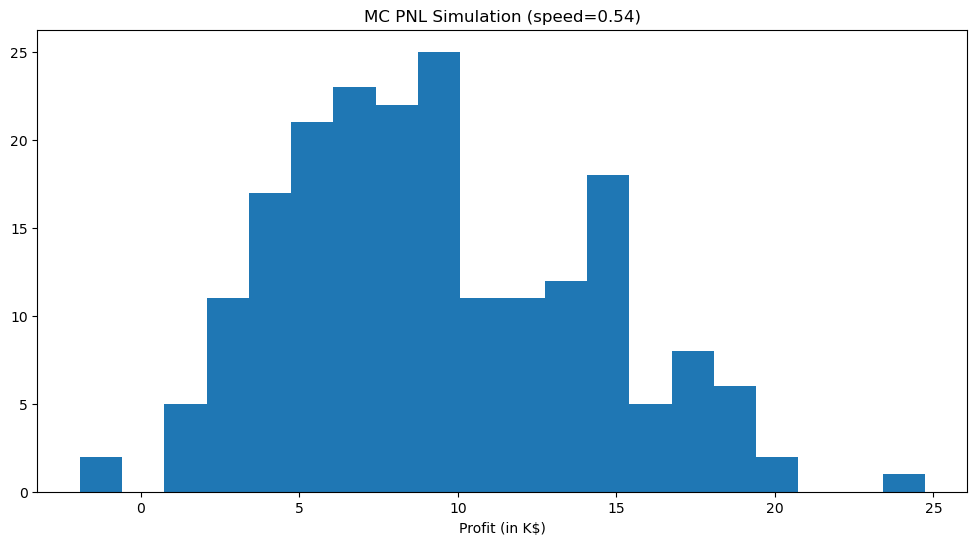

In [278]:
speed = 0.54
print(split(0.54))
alpha = 5
sim_pnl = mc_pnl(alpha, speed)
plt.figure(figsize=(12, 6))
plt.hist(sim_pnl, bins=20)
plt.title(f"MC PNL Simulation (speed={speed})")
plt.xlabel("Profit (in K$)")
plt.show()

Beta Distribution

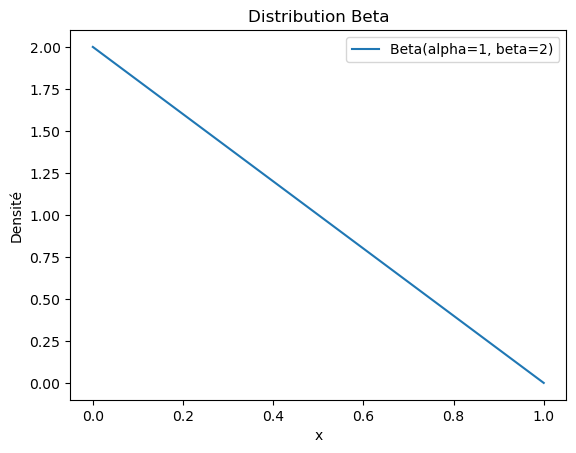

In [282]:
alpha, beta_param = 1, 2

x = np.linspace(0, 1, 200)
y = beta.pdf(x, alpha, beta_param)

plt.plot(x, y, label=f'Beta(alpha={alpha}, beta={beta_param})')
plt.xlabel('x')
plt.ylabel('Densité')
plt.title('Distribution Beta')
plt.legend()
plt.show()

Bivariate PNL 25-th Percentile as a Function of Alpha and Speed

In [283]:
X = 0.25
alpha_range = np.arange(1, 5.1, 0.1)
speed_range = np.arange(0.01, 0.91, 0.01)

# Fonction pour obtenir le quantile X de la série renvoyée par mc_pnl
def quantile_surface(X, alpha_range, speed_range):
    surface = np.zeros((len(speed_range), len(alpha_range)))
    for i, speed in enumerate(tqdm(speed_range, desc='Speed')):
        for j, alpha in enumerate(alpha_range):
            pnl_series = mc_pnl(alpha, speed)
            surface[i, j] = np.quantile(pnl_series, X)
    return surface

# Calcul de la surface
surface = quantile_surface(X, alpha_range, speed_range)

# Affichage interactif avec plotly
fig = go.Figure(data=[go.Surface(z=surface, x=alpha_range, y=speed_range)])
fig.update_layout(title=f'Surface du quantile {X} du PNL',
                  scene=dict(xaxis_title='Alpha', yaxis_title='Speed', zaxis_title='PNL'),
                  autosize=True, width=1000, height=700)
fig.show()

# Fonction de maximisation du quantile sur la surface

def maximize_surface(surface, alpha_range, speed_range):
    idx = np.unravel_index(np.argmax(surface), surface.shape)
    best_speed = speed_range[idx[0]]
    best_alpha = alpha_range[idx[1]]
    best_value = surface[idx]
    return best_alpha, best_speed, best_value

best_alpha, best_speed, best_value = maximize_surface(surface, alpha_range, speed_range)
print(f"Maximum quantile {X} du PNL atteint pour alpha={best_alpha:.2f}, speed={best_speed:.2f} : {best_value:.2f}")


Speed:   0%|          | 0/90 [00:00<?, ?it/s]

/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_43235/3092380824.py:32: FutureWarning:

The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.



Maximum quantile 0.25 du PNL atteint pour alpha=1.00, speed=0.30 : 184.27


Marginal Distribution for 25th Percentile of Speed with Alpha Value Discrete Likelihood

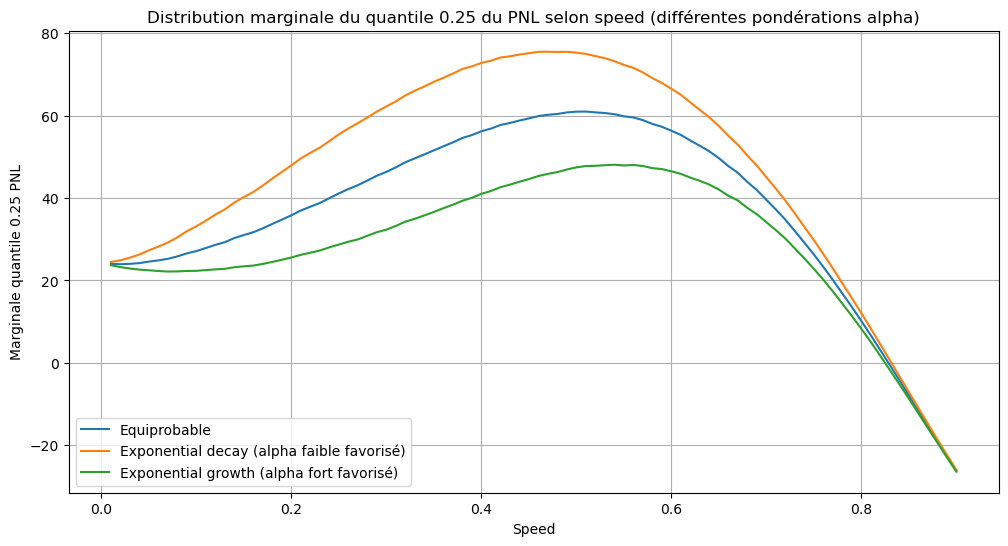

Equiprobable: max à speed=0.51, quantile 0.25 du PNL=61.01
Exponential decay: max à speed=0.47, quantile 0.25 du PNL=75.53
Exponential growth: max à speed=0.54, quantile 0.25 du PNL=48.10


In [284]:
# Distribution marginale du quantile X du PNL en fonction de speed
# Marginalisation sur alpha avec différentes pondérations

# 1. Equiprobable
alpha_probs_equi = np.ones(len(alpha_range)) / len(alpha_range)

# 2. Exponential decay (premier alpha 3x plus probable que le dernier)
lambda_decay = np.log(3) / (len(alpha_range) - 1)
alpha_probs_decay = np.exp(-lambda_decay * np.arange(len(alpha_range)))
alpha_probs_decay /= alpha_probs_decay.sum()

# 3. Exponential growth (dernier alpha 3x plus probable que le premier)
lambda_growth = np.log(3) / (len(alpha_range) - 1)
alpha_probs_growth = np.exp(lambda_growth * np.arange(len(alpha_range)))
alpha_probs_growth /= alpha_probs_growth.sum()

# Marginales
marg_equi = np.dot(surface, alpha_probs_equi)
marg_decay = np.dot(surface, alpha_probs_decay)
marg_growth = np.dot(surface, alpha_probs_growth)

plt.figure(figsize=(12, 6))
plt.plot(speed_range, marg_equi, label='Equiprobable')
plt.plot(speed_range, marg_decay, label='Exponential decay (alpha faible favorisé)')
plt.plot(speed_range, marg_growth, label='Exponential growth (alpha fort favorisé)')
plt.xlabel('Speed')
plt.ylabel(f'Marginale quantile {X} PNL')
plt.title(f'Distribution marginale du quantile {X} du PNL selon speed (différentes pondérations alpha)')
plt.legend()
plt.grid(True)
plt.show()

# Afficher les max pour chaque cas
for name, marg in zip([
    'Equiprobable',
    'Exponential decay',
    'Exponential growth'
], [marg_equi, marg_decay, marg_growth]):
    idx_max = np.argmax(marg)
    best_speed = speed_range[idx_max]
    best_pnl = marg[idx_max]
    print(f"{name}: max à speed={best_speed:.2f}, quantile {X} du PNL={best_pnl:.2f}")


Bivariate PNL 50-th Percentile as a Function of Alpha and Speed

In [285]:
X = 0.5

# Calcul de la surface
surface2 = quantile_surface(X, alpha_range, speed_range)

# Affichage interactif avec plotly
fig = go.Figure(data=[go.Surface(z=surface2, x=alpha_range, y=speed_range)])
fig.update_layout(title=f'Surface du quantile {X} du PNL',
                  scene=dict(xaxis_title='Alpha', yaxis_title='Speed', zaxis_title='PNL'),
                  autosize=True, width=1000, height=700)
fig.show()

best_alpha, best_speed, best_value = maximize_surface(surface2, alpha_range, speed_range)
print(f"Maximum quantile {X} du PNL atteint pour alpha={best_alpha:.2f}, speed={best_speed:.2f} : {best_value:.2f}")


Speed:   0%|          | 0/90 [00:00<?, ?it/s]

/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_43235/3092380824.py:32: FutureWarning:

The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.



Maximum quantile 0.5 du PNL atteint pour alpha=1.00, speed=0.32 : 192.36


Marginal Distribution for 50th Percentile of Speed with Alpha Value Discrete Likelihood

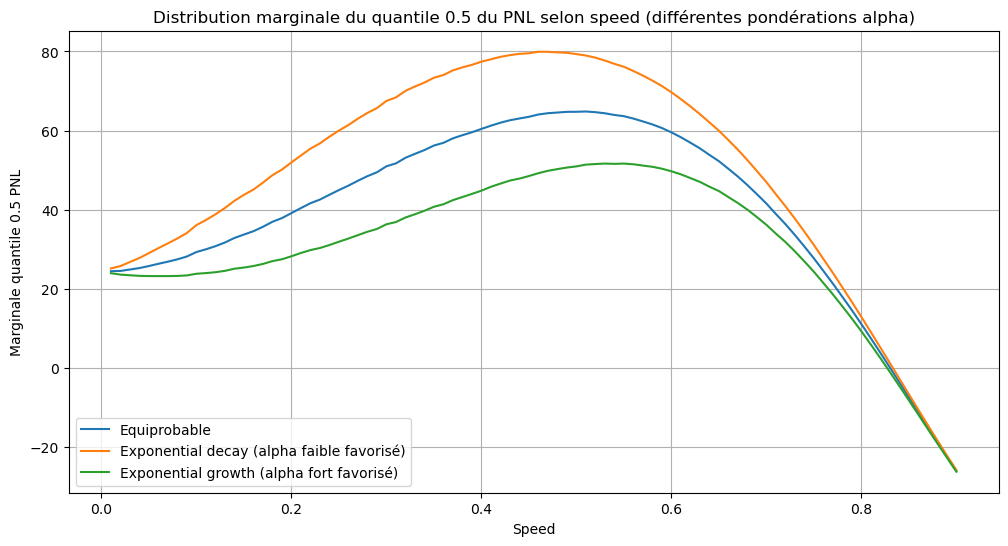

Equiprobable: max à speed=0.51, quantile 0.5 du PNL=64.81
Exponential decay: max à speed=0.46, quantile 0.5 du PNL=79.92
Exponential growth: max à speed=0.53, quantile 0.5 du PNL=51.65


In [288]:
# Distribution marginale du quantile X du PNL en fonction de speed
# Marginalisation sur alpha avec différentes pondérations

# 1. Equiprobable
alpha_probs_equi = np.ones(len(alpha_range)) / len(alpha_range)

# 2. Exponential decay (premier alpha 3x plus probable que le dernier)
lambda_decay = np.log(3) / (len(alpha_range) - 1)
alpha_probs_decay = np.exp(-lambda_decay * np.arange(len(alpha_range)))
alpha_probs_decay /= alpha_probs_decay.sum()

# 3. Exponential growth (dernier alpha 3x plus probable que le premier)
lambda_growth = np.log(3) / (len(alpha_range) - 1)
alpha_probs_growth = np.exp(lambda_growth * np.arange(len(alpha_range)))
alpha_probs_growth /= alpha_probs_growth.sum()

# Marginales
marg_equi = np.dot(surface2, alpha_probs_equi)
marg_decay = np.dot(surface2, alpha_probs_decay)
marg_growth = np.dot(surface2, alpha_probs_growth)

plt.figure(figsize=(12, 6))
plt.plot(speed_range, marg_equi, label='Equiprobable')
plt.plot(speed_range, marg_decay, label='Exponential decay (alpha faible favorisé)')
plt.plot(speed_range, marg_growth, label='Exponential growth (alpha fort favorisé)')
plt.xlabel('Speed')
plt.ylabel(f'Marginale quantile {X} PNL')
plt.title(f'Distribution marginale du quantile {X} du PNL selon speed (différentes pondérations alpha)')
plt.legend()
plt.grid(True)
plt.show()

# Afficher les max pour chaque cas
for name, marg in zip([
    'Equiprobable',
    'Exponential decay',
    'Exponential growth'
], [marg_equi, marg_decay, marg_growth]):
    idx_max = np.argmax(marg)
    best_speed = speed_range[idx_max]
    best_pnl = marg[idx_max]
    print(f"{name}: max à speed={best_speed:.2f}, quantile {X} du PNL={best_pnl:.2f}")


Alpha 0.51

In [ ]:
choosen = surface2.max(axis=1)
choosen

{'research': 0.11270000000000001, 'scale': 0.3773, 'speed': 0.51}


/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_55341/2586648045.py:5: RuntimeWarning: invalid value encountered in log
  def objective(x): return np.log(x) - np.exp(x)


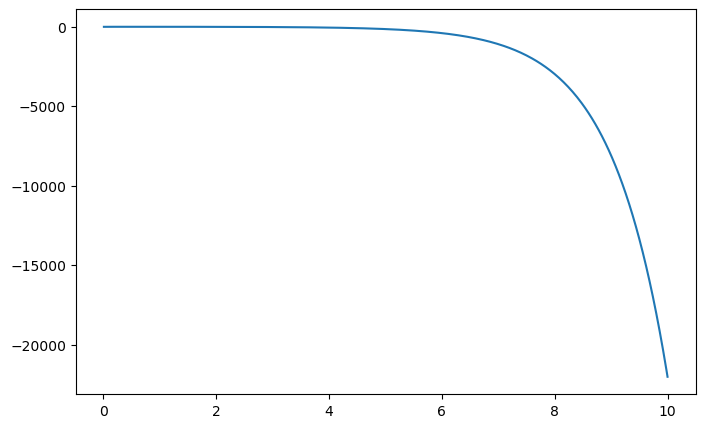

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -inf
        x: [ 1.044e+03]
      nit: 1
      jac: [       nan]
 hess_inv: [[1]]
     nfev: 224
     njev: 112


/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_55341/2586648045.py:5: RuntimeWarning: overflow encountered in exp
  def objective(x): return np.log(x) - np.exp(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_55341/2586648045.py:5: RuntimeWarning: overflow encountered in exp
  def objective(x): return np.log(x) - np.exp(x)
/var/folders/z6/j_nqb41d7p71wfmbz0m97p200000gn/T/ipykernel_55341/2586648045.py:5: RuntimeWarning: overflow encountered in exp
  def objective(x): return np.log(x) - np.exp(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


In [12]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

def objective(x): return np.log(x) - np.exp(x)

x = np.linspace(-10, 10, 1000)
y = [objective(i) for i in x]
plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.show()

z = minimize(objective, 10)
print(z)